In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Heart Disease EDA - Simple and Clean

File: `heart.csv` has 918 rows and 12 columns. Target is `HeartDisease` (0 = No, 1 = Yes).

In [77]:
# Load data and see basic shape
df = pd.read_csv('heart.csv')
print(df.shape)
print(list(df.columns))
df.head()

(920, 12)
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
2,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
3,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
4,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1


In [78]:
# Data types and summary
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             920 non-null    int64  
 1   Sex             920 non-null    str    
 2   ChestPainType   920 non-null    str    
 3   RestingBP       920 non-null    int64  
 4   Cholesterol     920 non-null    int64  
 5   FastingBS       920 non-null    int64  
 6   RestingECG      920 non-null    str    
 7   MaxHR           920 non-null    int64  
 8   ExerciseAngina  920 non-null    str    
 9   Oldpeak         920 non-null    float64
 10  ST_Slope        920 non-null    str    
 11  HeartDisease    920 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.4 KB


,count,mean,std,min,25%,50%,75%,max
Age,920.0,53.486957,9.437028,28.0,47.00,54.00,60.0,77.0
RestingBP,920.0,132.402174,18.495866,0.0,120.00,130.00,140.0,200.0
Cholesterol,920.0,198.939130,109.312734,0.0,173.75,223.00,267.0,603.0
FastingBS,920.0,0.232609,0.422725,0.0,0.00,0.00,0.0,1.0
MaxHR,920.0,136.883696,25.482516,60.0,120.00,138.00,156.0,202.0
Oldpeak,920.0,0.885435,1.066211,-2.6,0.00,0.55,1.5,6.2
HeartDisease,920.0,0.552174,0.497541,0.0,0.00,1.00,1.0,1.0


In [79]:
# 1. Check missing values and duplicates
# No missing values here, but we still check
print(df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
print(df.nunique())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Duplicates: 2
Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64


In [80]:
# 2. Zero means missing for these two columns
# RestingBP and Cholesterol can never be 0 in real life
print('RestingBP = 0:', (df['RestingBP'] == 0).sum())
print('Cholesterol = 0:', (df['Cholesterol'] == 0).sum())
print('Cholesterol 0 %:', round((df['Cholesterol'] == 0).mean() * 100, 1))
print(pd.crosstab(df['Cholesterol'] == 0, df['HeartDisease']))

RestingBP = 0: 1
Cholesterol = 0: 172
Cholesterol 0 %: 18.7
HeartDisease    0    1
Cholesterol           
False         392  356
True           20  152


## Target: HeartDisease

HeartDisease
1    508
0    412
Name: count, dtype: int64
HeartDisease
1    55.2
0    44.8
Name: proportion, dtype: float64


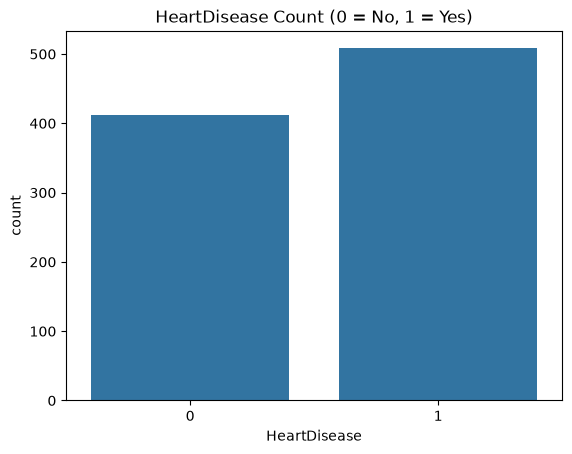

In [81]:
# 3. How many sick vs healthy?
print(df['HeartDisease'].value_counts())
print((df['HeartDisease'].value_counts(normalize=True) * 100).round(1))

sns.countplot(data=df, x='HeartDisease')
plt.title('HeartDisease Count (0 = No, 1 = Yes)')
plt.show()

## Numbers: distribution

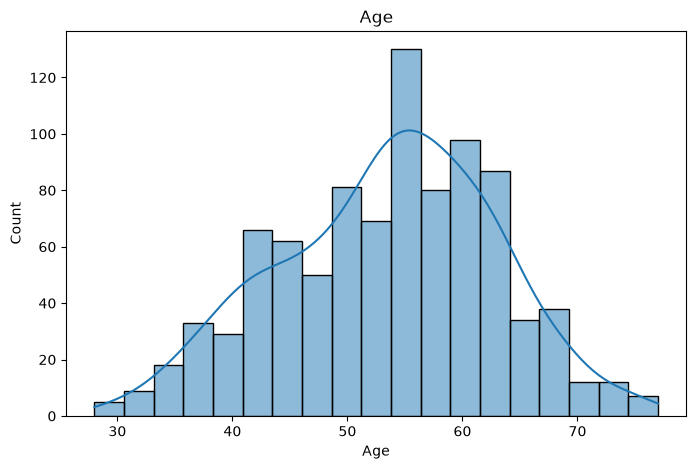

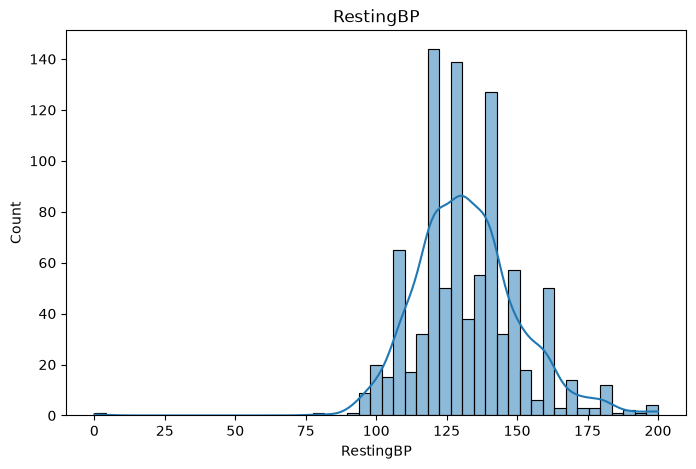

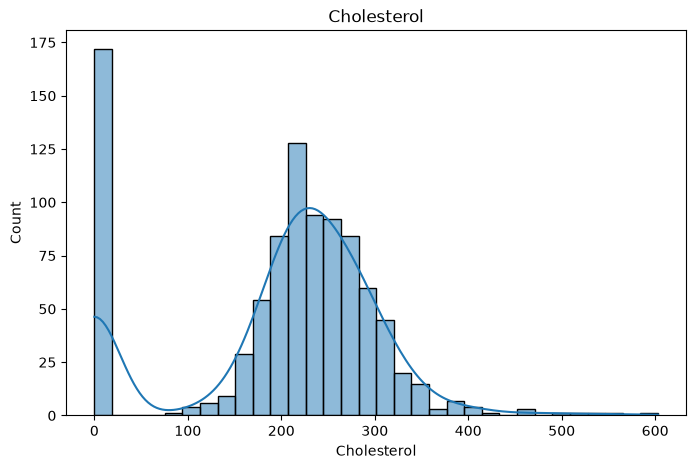

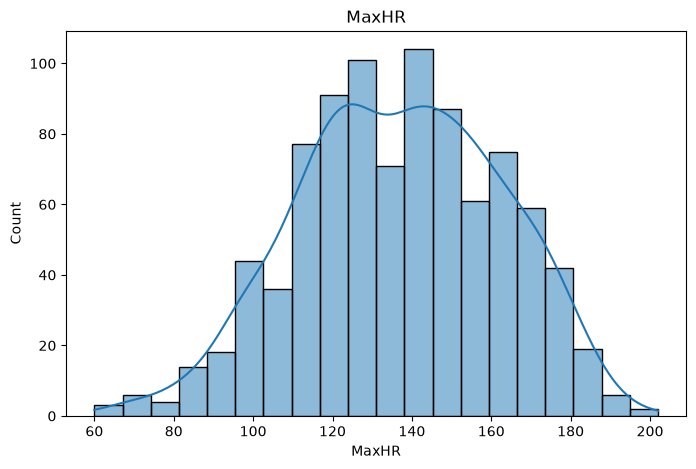

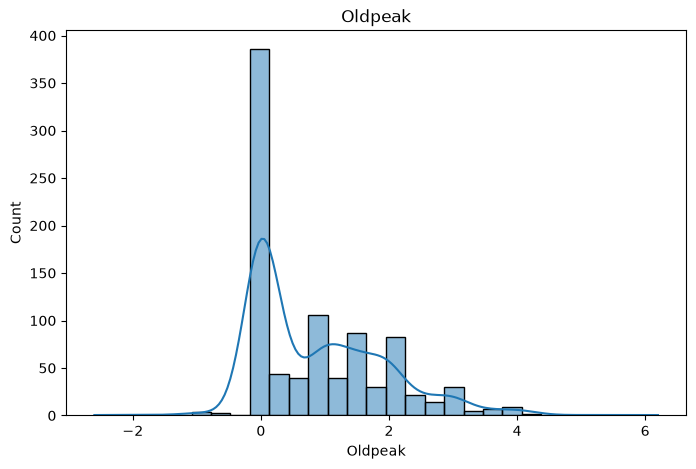

In [82]:
# 4. See each number column one by one
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(x=df[col], kde=True)
    plt.title(col)
    plt.show()

## Text columns: distribution

Sex
Sex
M    726
F    194
Name: count, dtype: int64


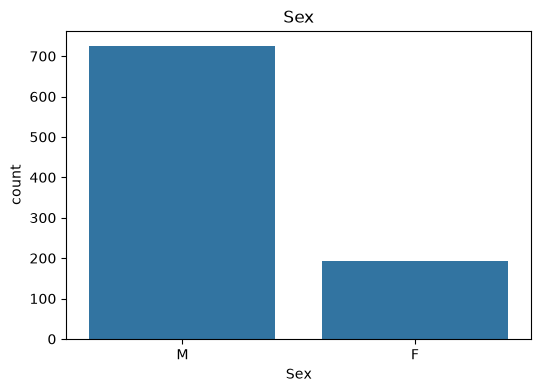

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    175
TA      46
Name: count, dtype: int64


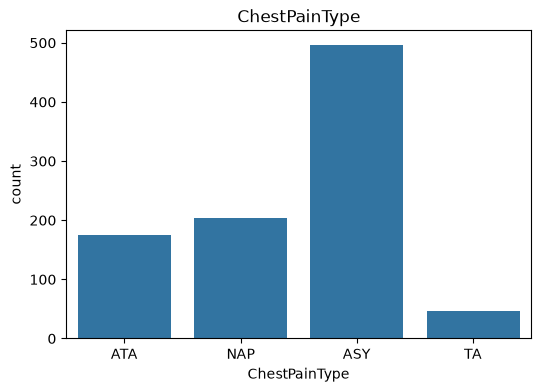

RestingECG
RestingECG
Normal    554
LVH       188
ST        178
Name: count, dtype: int64


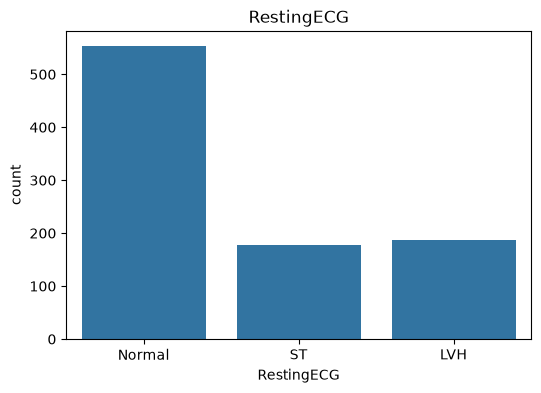

ExerciseAngina
ExerciseAngina
N    549
Y    371
Name: count, dtype: int64


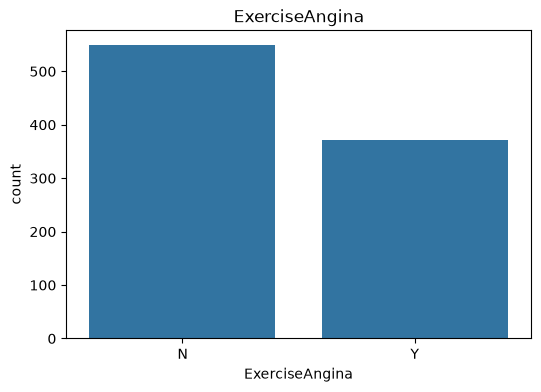

ST_Slope
ST_Slope
Flat    460
Up      397
Down     63
Name: count, dtype: int64


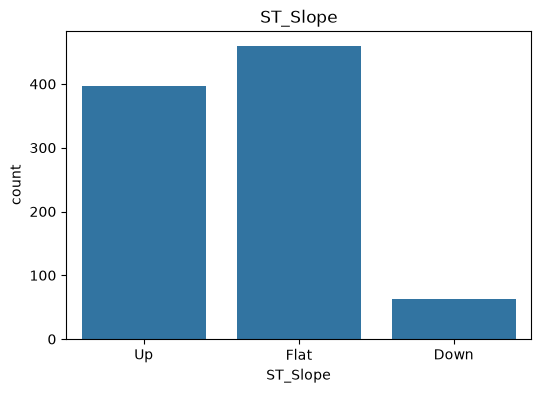

In [83]:
# 5. See each text column one by one
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in cat_cols:
    print(col)
    print(df[col].value_counts())
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.show()

## Numbers vs Target

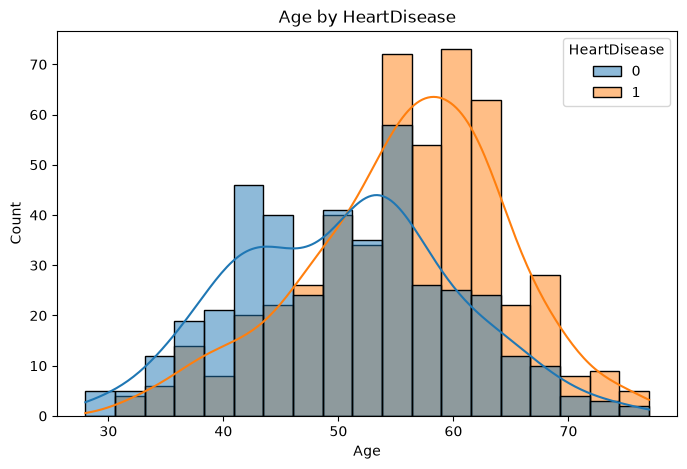

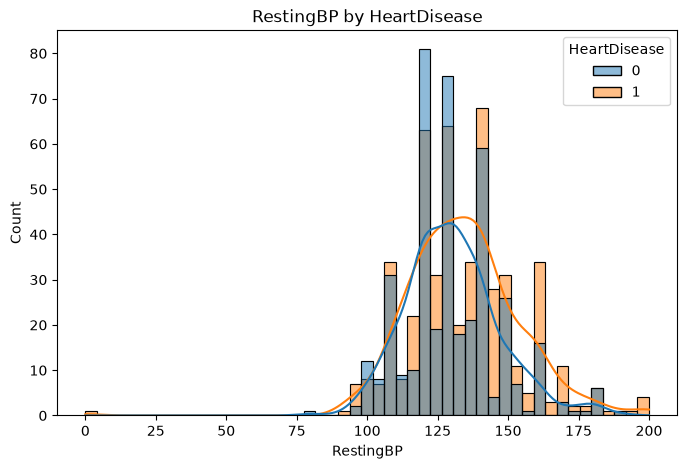

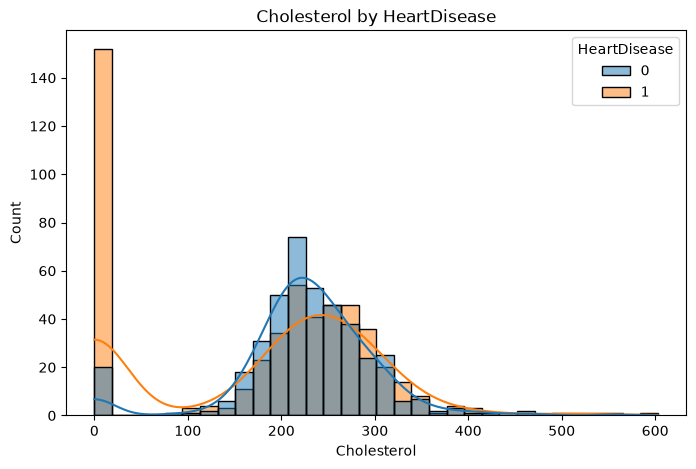

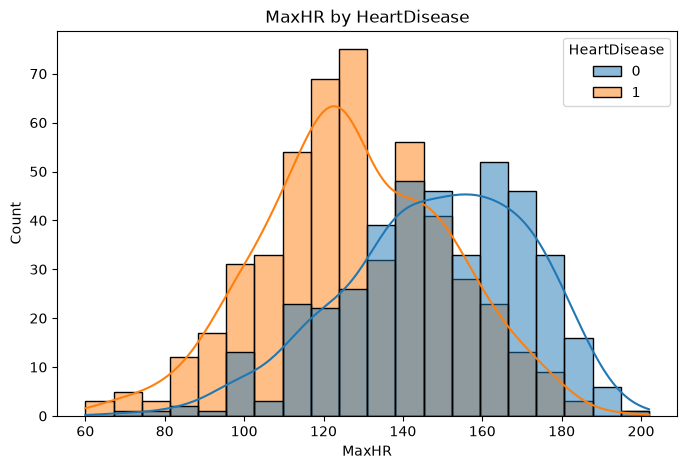

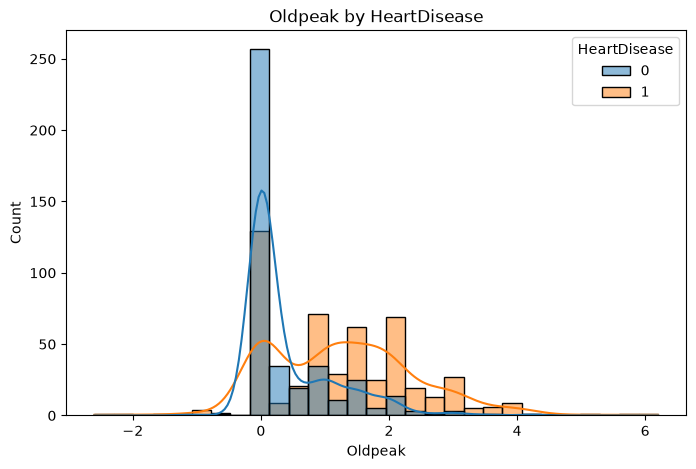

In [84]:
# 6. Do sick people have different numbers?
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue='HeartDisease', kde=True)
    plt.title(col + ' by HeartDisease')
    plt.show()

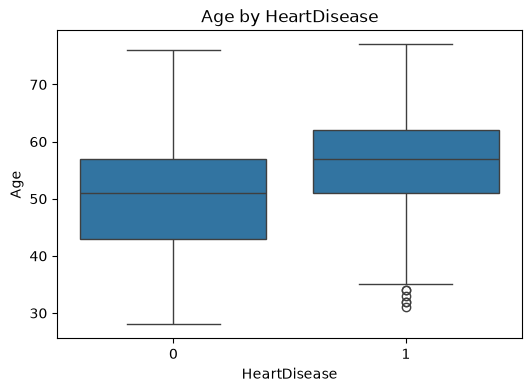

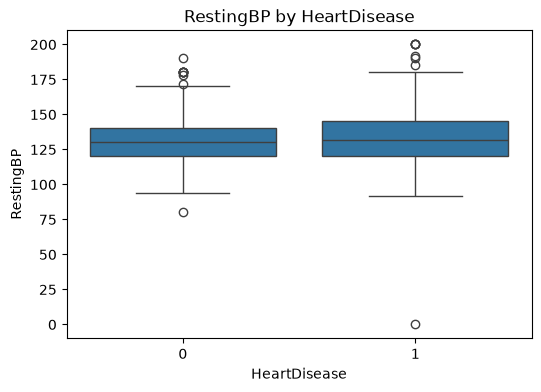

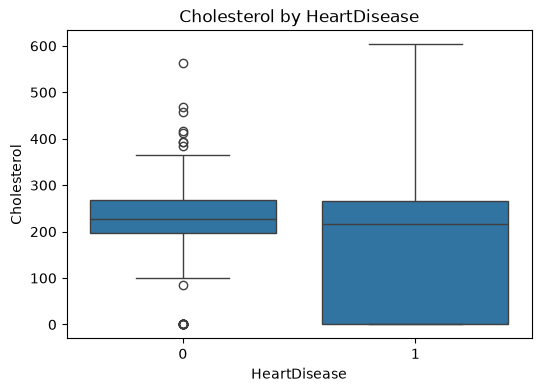

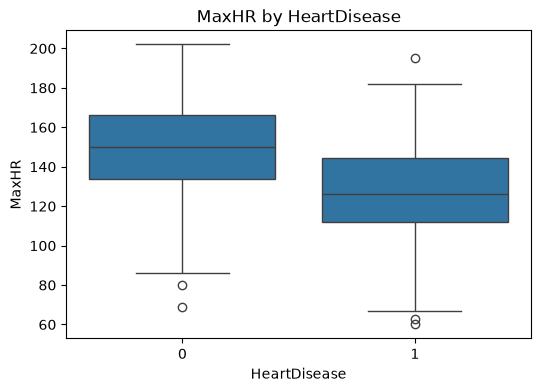

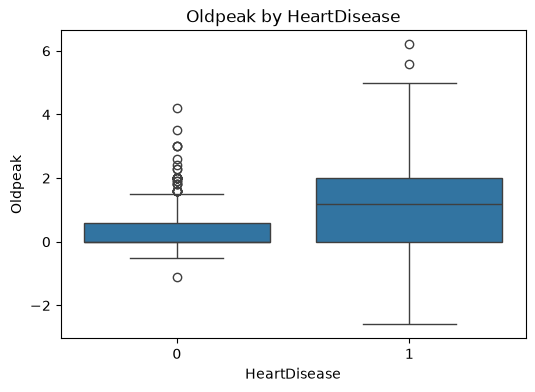

In [85]:
# Same thing with boxplot. Easy to see median difference.
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='HeartDisease', y=col)
    plt.title(col + ' by HeartDisease')
    plt.show()

In [86]:
# Average numbers for sick vs healthy
print(df.groupby('HeartDisease')[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']].mean().round(1))

               Age  RestingBP  Cholesterol  MaxHR  Oldpeak
HeartDisease                                              
0             50.5      130.2        227.3  148.3      0.4
1             55.9      134.2        175.9  127.7      1.3


## Text columns vs Target

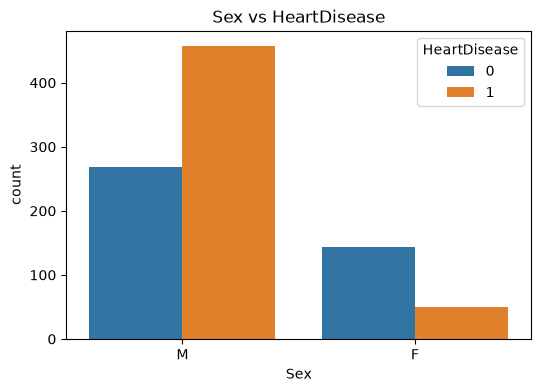

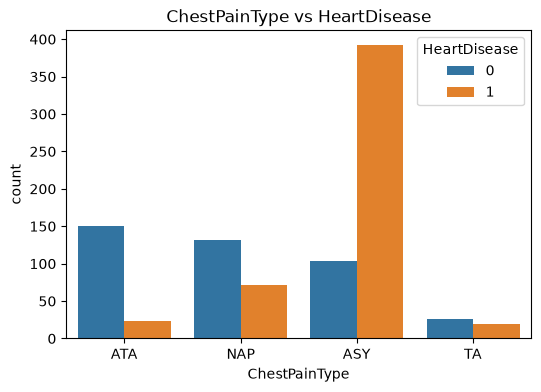

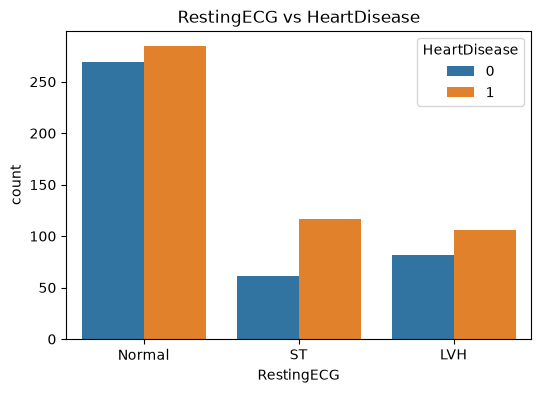

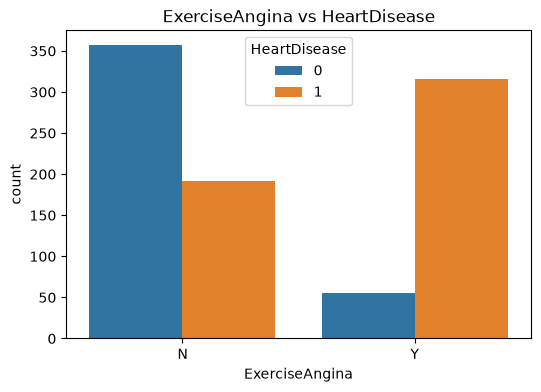

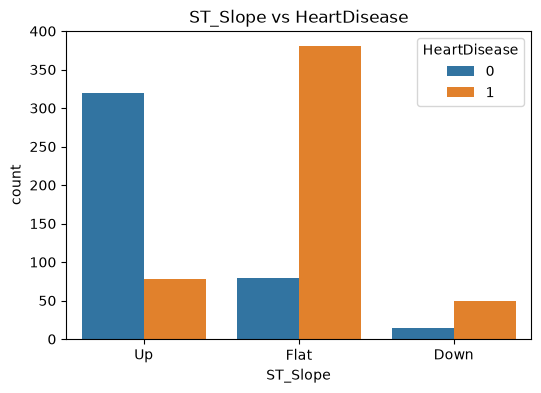

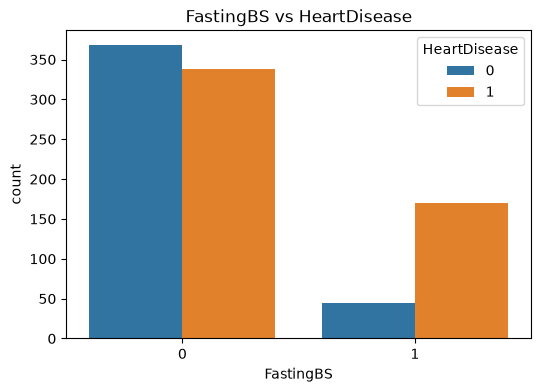

In [87]:
# 7. Which group is more sick?
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='HeartDisease')
    plt.title(col + ' vs HeartDisease')
    plt.show()

In [88]:
# Disease rate. Mean = share of sick. 0.8 = 80% sick.
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for col in cat_cols:
    print(col)
    print((df.groupby(col, observed=True)['HeartDisease'].mean()).round(3))

Sex
Sex
F    0.258
M    0.631
Name: HeartDisease, dtype: float64
ChestPainType
ChestPainType
ASY    0.790
ATA    0.137
NAP    0.355
TA     0.435
Name: HeartDisease, dtype: float64
RestingECG
RestingECG
LVH       0.564
Normal    0.514
ST        0.657
Name: HeartDisease, dtype: float64
ExerciseAngina
ExerciseAngina
N    0.350
Y    0.852
Name: HeartDisease, dtype: float64
ST_Slope
ST_Slope
Down    0.778
Flat    0.828
Up      0.196
Name: HeartDisease, dtype: float64
FastingBS
FastingBS
0    0.479
1    0.794
Name: HeartDisease, dtype: float64


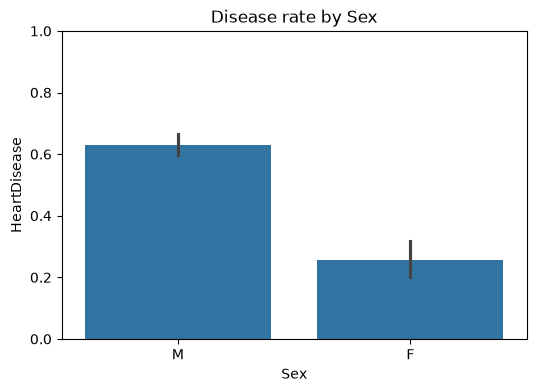

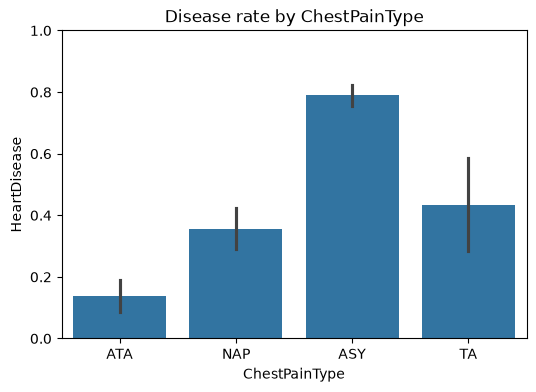

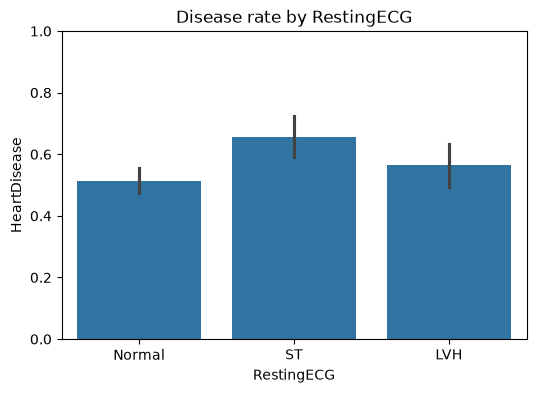

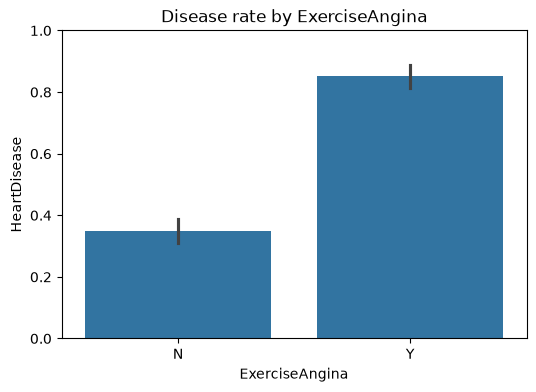

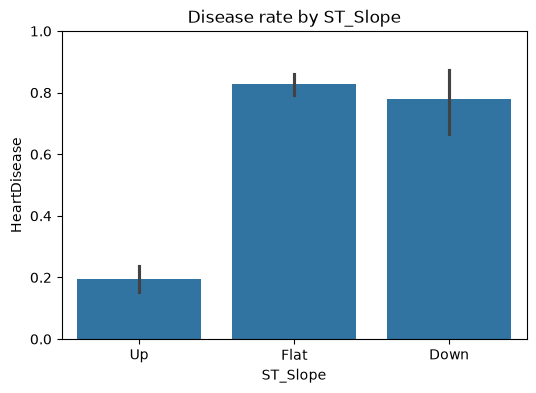

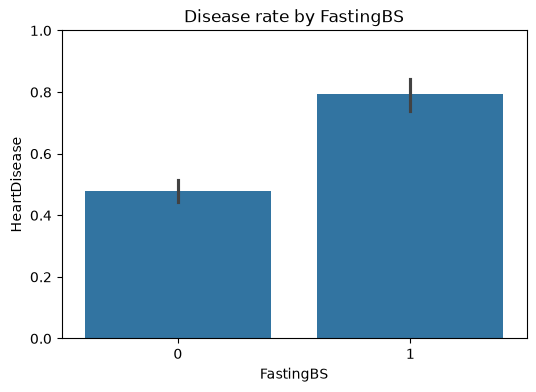

In [89]:
# Disease rate bar plot. This is better than sum.
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x=col, y='HeartDisease')
    plt.ylim(0, 1)
    plt.title('Disease rate by ' + col)
    plt.show()

## Important: Cholesterol zero problem

In [90]:
# Cholesterol 0 rows are mostly sick, so average looks wrong
print('With zeros:')
print(df.groupby('HeartDisease')['Cholesterol'].mean().round(1))

print('Without zeros:')
df_good = df[df['Cholesterol'] > 0]
print(df_good.groupby('HeartDisease')['Cholesterol'].mean().round(1))
print('Without zeros, sick group has higher cholesterol. This makes sense.')

With zeros:
HeartDisease
0    227.3
1    175.9
Name: Cholesterol, dtype: float64
Without zeros:
HeartDisease
0    238.9
1    251.1
Name: Cholesterol, dtype: float64
Without zeros, sick group has higher cholesterol. This makes sense.


## Outliers: simple check

In [91]:
# Simple IQR rule to count outliers
for col in ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(col, 'skew:', round(df[col].skew(), 2), 'outliers:', n_out)

Age skew: -0.19 outliers: 0
RestingBP skew: 0.18 outliers: 28
Cholesterol skew: -0.61 outliers: 184
MaxHR skew: -0.15 outliers: 2
Oldpeak skew: 1.03 outliers: 16


## Correlation

HeartDisease    1.000
Oldpeak         0.405
Age             0.284
FastingBS       0.268
RestingBP       0.107
Cholesterol    -0.234
MaxHR          -0.402
Name: HeartDisease, dtype: float64


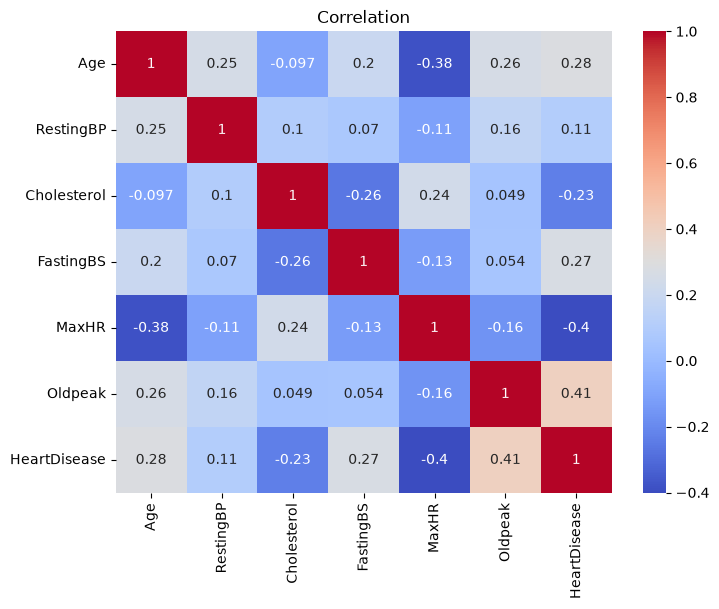

In [92]:
# Which numbers go up or down with disease?
corr = df[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']].corr()
print(corr['HeartDisease'].sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

## Groups and best combination

AgeGroup
<40      0.340
40-50    0.415
50-60    0.583
60+      0.729
Name: HeartDisease, dtype: float64


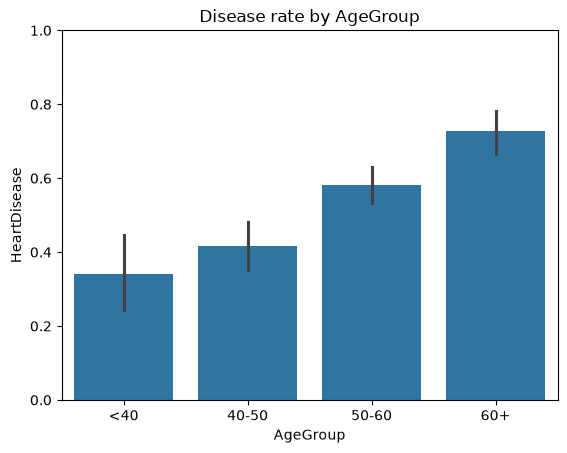

In [93]:
# Older people are more sick
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 40, 50, 60, 100], labels=['<40', '40-50', '50-60', '60+'])
print(df.groupby('AgeGroup', observed=True)['HeartDisease'].mean().round(3))

sns.barplot(data=df, x='AgeGroup', y='HeartDisease')
plt.ylim(0, 1)
plt.title('Disease rate by AgeGroup')
plt.show()

OldpeakBin
<=0    0.347
0-1    0.520
1-2    0.764
>2     0.910
Name: HeartDisease, dtype: float64


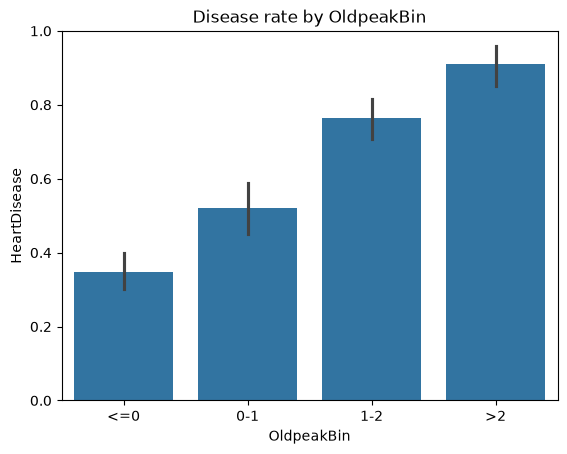

In [94]:
# Higher Oldpeak means more sick
df['OldpeakBin'] = pd.cut(df['Oldpeak'], bins=[-3, 0, 1, 2, 7], labels=['<=0', '0-1', '1-2', '>2'])
print(df.groupby('OldpeakBin', observed=True)['HeartDisease'].mean().round(3))

sns.barplot(data=df, x='OldpeakBin', y='HeartDisease')
plt.ylim(0, 1)
plt.title('Disease rate by OldpeakBin')
plt.show()

ST_Slope       Down  Flat    Up
ChestPainType                  
ASY            0.91  0.91  0.46
ATA            0.33  0.56  0.04
NAP            0.50  0.67  0.08
TA             0.25  0.68  0.20


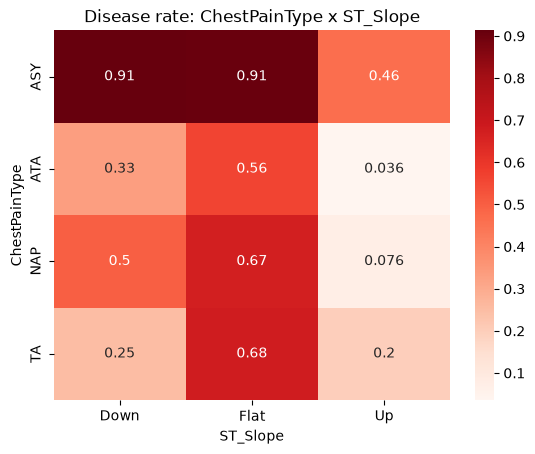

ASY + Flat = ~0.91 sick. ATA + Up = ~0.04 sick.


In [95]:
# Best combination: ChestPainType + ST_Slope
table = pd.crosstab(df['ChestPainType'], df['ST_Slope'], values=df['HeartDisease'], aggfunc='mean')
print(table.round(2))

sns.heatmap(table, annot=True, cmap='Reds')
plt.title('Disease rate: ChestPainType x ST_Slope')
plt.show()
print('ASY + Flat = ~0.91 sick. ATA + Up = ~0.04 sick.')

## Summary

- 918 rows, no missing values, no duplicates.
- Target: 55.3% sick, 44.7% healthy.
- Cholesterol 0 in 172 rows (18.7%). Treat as missing.
- High risk: ASY, Flat slope, ExerciseAngina Y, FastingBS 1, Male, older age, low MaxHR, high Oldpeak.
- Low risk: ATA, Up slope, ExerciseAngina N.

## Data Cleaning

Issues found in EDA:
- 920 rows but 2 exact duplicates -> keep 918.
- No `NaN`, but `RestingBP = 0` (1 row) and `Cholesterol = 0` (172 rows, 18.7%) are impossible -> treat as missing.
- Deleting 172 rows loses 18.7% and is biased (88% of them are sick vs 55% overall), so median impute.
- Other columns: categories clean, `Oldpeak` negatives (13) are kept, true high outliers kept.


In [113]:
# 0. Start fresh from file (EDA added AgeGroup/OldpeakBin to df, so reload)
df_clean = pd.read_csv('heart.csv')
print(df_clean.shape)
print(list(df_clean.columns))


(920, 12)
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [114]:
# 1. Remove exact duplicates
print('Before:', df_clean.shape)
print('Duplicates:', df_clean.duplicated().sum())
print(df_clean[df_clean.duplicated(keep=False)].sort_values(list(df_clean.columns)).head(4))
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print('After:', df_clean.shape)


Before: (920, 12)
Duplicates: 2
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   40   M           ATA        140          289          0     Normal    172   
7   45   F           ATA        130          237          0     Normal    170   
8   45   F           ATA        130          237          0     Normal    170   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      0.0       Up             0  
7              N      0.0       Up             0  
8              N      0.0       Up             0  
After: (918, 12)


In [115]:
# 2. Zero means missing for RestingBP and Cholesterol
print('RestingBP = 0:', (df_clean['RestingBP'] == 0).sum())
print('Cholesterol = 0:', (df_clean['Cholesterol'] == 0).sum())
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, float('nan'))
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, float('nan'))
print(df_clean[['RestingBP', 'Cholesterol']].isna().sum())


RestingBP = 0: 1
Cholesterol = 0: 172
RestingBP        1
Cholesterol    172
dtype: int64


In [116]:
# 3. Fill missing with median of non-zero values (overall median, no leakage)
med_bp = df_clean['RestingBP'].median()
med_ch = df_clean['Cholesterol'].median()
print('Median RestingBP:', med_bp)
print('Median Cholesterol:', med_ch)
df_clean['RestingBP'] = df_clean['RestingBP'].fillna(med_bp)
df_clean['Cholesterol'] = df_clean['Cholesterol'].fillna(med_ch)
# back to int (medians are .0)
df_clean['RestingBP'] = df_clean['RestingBP'].astype(int)
df_clean['Cholesterol'] = df_clean['Cholesterol'].astype(int)
print(df_clean[['RestingBP', 'Cholesterol']].describe().round(1))


Median RestingBP: 130.0
Median Cholesterol: 237.0
       RestingBP  Cholesterol
count      918.0        918.0
mean       132.5        243.2
std         18.0         53.4
min         80.0         85.0
25%        120.0        214.0
50%        130.0        237.0
75%        140.0        267.0
max        200.0        603.0


In [117]:
# 4. Final checks: no dups, no zeros, no NaN, dtypes ok
print('Shape:', df_clean.shape)
print('Duplicates:', df_clean.duplicated().sum())
print('RestingBP = 0:', (df_clean['RestingBP'] == 0).sum())
print('Cholesterol = 0:', (df_clean['Cholesterol'] == 0).sum())
print('Total NaN:', int(df_clean.isna().sum().sum()))
print(df_clean.dtypes)
# Fix check: Cholesterol correlation flips from negative to positive
df_raw = pd.read_csv('heart.csv').drop_duplicates()
print('Corr before:', round(df_raw['Cholesterol'].corr(df_raw['HeartDisease']), 3))
print('Corr after:', round(df_clean['Cholesterol'].corr(df_clean['HeartDisease']), 3))
print(df_clean.describe().round(1))


Shape: (918, 12)
Duplicates: 0
RestingBP = 0: 0
Cholesterol = 0: 0
Total NaN: 0
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object
Corr before: -0.233
Corr after: 0.076
         Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease
count  918.0      918.0        918.0      918.0  918.0    918.0         918.0
mean    53.5      132.5        243.2        0.2  136.8      0.9           0.6
std      9.4       18.0         53.4        0.4   25.5      1.1           0.5
min     28.0       80.0         85.0        0.0   60.0     -2.6           0.0
25%     47.0      120.0        214.0        0.0  120.0      0.0           0.0
50%     54.0      130.0        237.0        0.0  138.0      0.6           1.0
75%     60

In [118]:
# 5. Save cleaned data
df_clean.to_csv('heart_cleaned.csv', index=False)
print('Saved heart_cleaned.csv:', df_clean.shape)
df_clean.head()


Saved heart_cleaned.csv: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
